In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# =========================
# STEP 1: EXTRACT ZIP
# =========================
zip_path = "/content/archive (1).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP Extracted!")

# =========================
# STEP 2: SET CORRECT PATHS
# =========================
train_dir = "/content/dataset/Training"
test_dir = "/content/dataset/Testing"

print("Train folders:", os.listdir(train_dir))
print("Test folders:", os.listdir(test_dir))

# =========================
# STEP 3: PARAMETERS
# =========================
img_size = 224
batch_size = 32

# =========================
# STEP 4: DATA GENERATOR
# =========================
train_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

# =========================
# STEP 5: MODEL
# =========================
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))

# ✅ 4 classes hai
model.add(layers.Dense(train_generator.num_classes, activation='softmax'))

# =========================
# STEP 6: COMPILE
# =========================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# STEP 7: TRAIN
# =========================
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

# =========================
# STEP 8: EVALUATE
# =========================
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)

# =========================
# STEP 9: CLASS LABELS
# =========================
print("Class Indices:", train_generator.class_indices)

ZIP Extracted!
Train folders: ['notumor', 'meningioma', 'glioma', 'pituitary']
Test folders: ['notumor', 'meningioma', 'glioma', 'pituitary']
Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 655s 4s/step - accuracy: 0.7023 - loss: 0.7564 - val_accuracy: 0.7613 - val_loss: 0.8973
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 663s 4s/step - accuracy: 0.8739 - loss: 0.3478 - val_accuracy: 0.7975 - val_loss: 0.9247
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 636s 4s/step - accuracy: 0.9237 - loss: 0.2102 - val_accuracy: 0.8481 - val_loss: 0.9054
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 626s 4s/step - accuracy: 0.9680 - loss: 0.0973 - val_accuracy: 0.8800 - val_loss: 1.0953
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 622s 4s/step - accuracy: 0.9784 - loss: 0.0633 - val_accuracy: 0.8769 - val_loss: 1.3969
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 626s 4s/step - accuracy: 0.9866 - loss: 0.0358 - val_accuracy: 0.8706 - val_loss: 1.3851
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 624s 4s/step - accuracy: 0.9898 - loss: 0.0379 - val_accuracy: 0.8744 - val_loss: 1.0967
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 625s 4s/step - accuracy: 0.9900 - loss: 0.0278 - val_accu

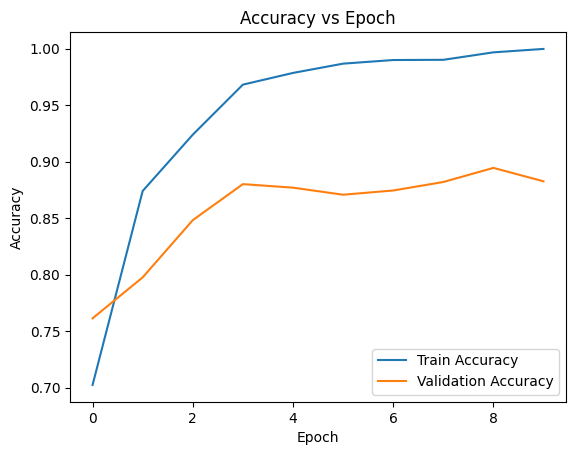

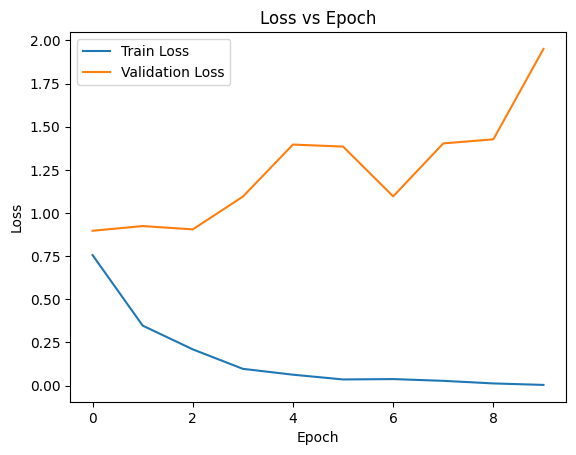

In [7]:
# =========================
# STEP 10: VISUALIZATION
# =========================
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss Graph
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()